# 10 · Navier–Stokes with PINNs — Reproducing the Raissi et al. (2019) Methodology

**Level:** Research
**Prerequisites:** entire Beginner–Advanced track, especially `07_inverse_parameter_estimation`

The headline result of Raissi, Perdikaris & Karniadakis (2019) is inferring the
**pressure field and viscosity** of an incompressible flow from **sparse velocity
measurements only** — pressure is never measured, yet the PINN reconstructs it
from the momentum equations. Their demonstration used a cylinder-wake dataset.

Here we reproduce their exact **methodology** on a problem with a known analytical
solution so the notebook is fully self-contained and runnable: the **2-D
Taylor–Green vortex**, an exact decaying solution of the incompressible
Navier–Stokes equations.

### Faithful ingredients from the paper
1. **Stream-function formulation** `u = ψ_y, v = -ψ_x` → incompressibility holds by construction.
2. Network outputs `(ψ, p)`; velocities obtained by autograd.
3. Momentum-equation residuals as the physics loss.
4. Viscosity `ν` treated as an **unknown learnable parameter** (inverse problem).
5. Training data = sparse `(u, v)` samples; pressure is *inferred*, recovered up to a constant.

### References
- Raissi, Perdikaris & Karniadakis (2019), *J. Comput. Phys.* 378:686-707
- Raissi, Yazdani & Karniadakis (2020), *Hidden fluid mechanics*, Science 367:1026-1030
- Cai et al. (2021/2022), *PINNs for fluid mechanics: A review*, Acta Mech. Sinica


## 1 · The Taylor–Green vortex — an exact solution of Navier–Stokes

### What is the incompressible Navier–Stokes equation?

The Navier–Stokes (NS) equations govern the motion of viscous, incompressible fluids (water, oil, air at low speed). In 2D they are a system of three coupled PDEs:

**x-momentum:**
$$u_t + u\,u_x + v\,u_y = -p_x + \nu(u_{xx} + u_{yy})$$

**y-momentum:**
$$v_t + u\,v_x + v\,v_y = -p_y + \nu(v_{xx} + v_{yy})$$

**Continuity (incompressibility):**
$$u_x + v_y = 0$$

where:
- $u(x,y,t)$: fluid velocity in the $x$-direction
- $v(x,y,t)$: fluid velocity in the $y$-direction  
- $p(x,y,t)$: pressure field
- $\nu$: kinematic viscosity (inverse Reynolds number: $\nu = 1/Re$)

**Left-hand sides** = inertial terms (fluid carries its own momentum)  
**Right-hand sides** = pressure gradient (drives flow) + viscous diffusion (slows/smooths flow)

The continuity equation $u_x + v_y = 0$ says: what flows in must flow out (incompressibility = no compression/expansion of the fluid).

### The Taylor–Green vortex — why it's the perfect test case

On $[0, 2\pi]^2$ with viscosity $\nu$, the exact solution is:

$$u = -\cos(x)\sin(y)\,e^{-2\nu t}$$
$$v = +\sin(x)\cos(y)\,e^{-2\nu t}$$  
$$p = -\tfrac{1}{4}(\cos(2x)+\cos(2y))\,e^{-4\nu t}$$

**Why this solution is special:**
1. It satisfies all three NS equations exactly — verified by substitution
2. The velocity field decays in time at rate $e^{-2\nu t}$ — viscosity dissipates kinetic energy
3. The pressure decays faster ($e^{-4\nu t}$) — it is a nonlinear function of velocity
4. It represents a **decaying vortex** — a swirling flow pattern that gradually smooths out
5. **Pressure is never observed** — we will only give the PINN velocity data and ask it to infer $p$

### Why pressure inference is remarkable

In the original Raissi et al. (2019) paper, the headline result was recovering the **pressure field around a cylinder** from velocity measurements alone. Pressure is hard and expensive to measure directly (it requires pressure taps or special sensors), but velocity can be measured by PIV (Particle Image Velocimetry). 

The PINN achieves this because the momentum equations **couple** pressure to velocity:
$$p_x = -u_t - u\,u_x - v\,u_y + \nu(u_{xx}+u_{yy})$$

If $u$ and $v$ are known, the right-hand side is fully determined, so $p$ can be recovered (up to a constant) by "integrating" this equation — which the PINN does implicitly through the physics loss.

### The stream-function formulation — guaranteeing incompressibility

Instead of directly predicting $(u, v, p)$, the network outputs $(\psi, p)$, and the velocities are derived:

$$u = +\frac{\partial \psi}{\partial y}, \qquad v = -\frac{\partial \psi}{\partial x}$$

**Why this is clever:** Substituting into the continuity equation:
$$u_x + v_y = \psi_{yx} + (-\psi_{xy}) = \psi_{yx} - \psi_{xy} = 0 \quad \checkmark$$

The divergence-free condition is satisfied **exactly and automatically** by any smooth $\psi$. This removes the continuity residual from the loss entirely, reducing the number of competing objectives and improving conditioning. It is one of the signature techniques of Raissi et al. (2019).

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

nu_true = 0.05
def tg(x, y, t):
    e2 = np.exp(-2*nu_true*t); e4 = np.exp(-4*nu_true*t)
    u = -np.cos(x)*np.sin(y)*e2
    v =  np.sin(x)*np.cos(y)*e2
    p = -0.25*(np.cos(2*x)+np.cos(2*y))*e4
    return u, v, p


Using device: cpu


### 📌 Code walkthrough — data generation

```python
nu_true = 0.05

N_data = 2000                         # 2000 velocity sensor readings
xd = rand(N_data) * 2*pi              # random x in [0, 2π]
yd = rand(N_data) * 2*pi              # random y in [0, 2π]
td = rand(N_data) * 1.0               # random t in [0, 1]
ud, vd, _ = tg(xd, yd, td)           # ← ground truth velocities (pressure DISCARDED)
ud += 0.01 * randn(N_data)            # add 1% noise to u
vd += 0.01 * randn(N_data)            # add 1% noise to v
```

**The underscore `_` after `tg(xd, yd, td)`** discards the pressure values — intentionally! The PINN will never see the pressure during training. It must infer $p$ purely from the momentum equations applied to the velocity data.

**Why 2000 sensor points?** NS is a 3-field, 3-equation system in 3D space-time $(x, y, t)$. More data is needed than the scalar 1-D problems. In the original paper, Raissi et al. used ~5000 points from a cylinder-wake simulation.

**Why `requires_grad_(True)` on the data points?**
```python
xd_t.requires_grad_(True); yd_t.requires_grad_(True)
```
At the sensor locations, we need to compute $u = \psi_y$ and $v = -\psi_x$ via autograd. Even though these are "data points," the stream-function formulation requires differentiating the network output w.r.t. the spatial inputs to get $(u, v)$ — so those spatial inputs need to track gradients.

**Collocation points (physics enforcement):**
```python
N_f = 6000      # 6000 interior points for physics residual
```
These are the "physics collocation" points — no data here, just enforcement of the NS equations. The $3\times$ ratio (6000 physics vs 2000 data) is typical: you need many physics points to cover the full space-time domain.

In [2]:
# --- Sparse, noisy velocity training data ---
N_data = 2000
xd = np.random.rand(N_data)*2*np.pi
yd = np.random.rand(N_data)*2*np.pi
td = np.random.rand(N_data)*1.0
ud, vd, _ = tg(xd, yd, td)
ud += 0.01*np.random.randn(N_data); vd += 0.01*np.random.randn(N_data)

to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=device).view(-1,1)
xd_t, yd_t, td_t = to_t(xd), to_t(yd), to_t(td)
xd_t.requires_grad_(True); yd_t.requires_grad_(True)   # needed: u=ψ_y, v=-ψ_x at data points
ud_t, vd_t = to_t(ud), to_t(vd)

# collocation points for the physics residual
N_f = 6000
xf = torch.rand(N_f,1,device=device)*2*np.pi
yf = torch.rand(N_f,1,device=device)*2*np.pi
tf = torch.rand(N_f,1,device=device)*1.0
for z in (xf,yf,tf): z.requires_grad_(True)


In [3]:
class NSNet(nn.Module):
    # inputs (x,y,t) -> outputs (psi, p)
    def __init__(self, layers):
        super().__init__()
        seq=[]
        for i in range(len(layers)-1):
            seq.append(nn.Linear(layers[i],layers[i+1]))
            if i<len(layers)-2: seq.append(nn.Tanh())
        self.net=nn.Sequential(*seq)
        for mo in self.net:
            if isinstance(mo,nn.Linear):
                nn.init.xavier_normal_(mo.weight); nn.init.zeros_(mo.bias)
        self.log_nu = nn.Parameter(torch.tensor(np.log(0.2), dtype=torch.float32))  # wrong start
    @property
    def nu(self): return torch.exp(self.log_nu)
    def forward(self,x,y,t): return self.net(torch.cat([x,y,t],1))

model = NSNet([3,60,60,60,60,2]).to(device)

def grad(o,i): return torch.autograd.grad(o,i,torch.ones_like(o),create_graph=True)[0]

def uvp(model,x,y,t):
    out = model(x,y,t); psi, p = out[:,0:1], out[:,1:2]
    u =  grad(psi,y)               # u = ψ_y
    v = -grad(psi,x)               # v = -ψ_x  -> divergence-free by construction
    return u, v, p


### 📌 Architecture deep-dive — the NSNet

```python
class NSNet(nn.Module):
    # Inputs: (x, y, t) — 3 inputs
    # Outputs: (ψ, p)   — 2 outputs (NOT u and v directly!)
    
    self.log_nu = nn.Parameter(tensor(log(0.2)))   # ← unknown viscosity, deliberately wrong
    
    @property
    def nu(self): return exp(self.log_nu)            # ← always positive
```

**Key design choices:**

**1. Two outputs instead of three**
The network outputs $(\psi, p)$ rather than $(u, v, p)$. The velocities are recovered by automatic differentiation:
```python
def uvp(model, x, y, t):
    psi, p = model(x, y, t)
    u =  grad(psi, y)     # ∂ψ/∂y — one autograd call
    v = -grad(psi, x)     # -∂ψ/∂x — one autograd call
```
This is the stream-function trick: incompressibility is satisfied automatically.

**2. Wider and deeper: `[3→60→60→60→60→2]`**
Four hidden layers of 60 units each (vs. three layers of 40 in previous notebooks). NS is genuinely harder than scalar ODEs:
- Three coupled equations with nonlinear advection terms ($u\,u_x$, $u\,v_y$, etc.)
- Mixed spatial-temporal derivatives (8 second-order partials needed)
- Unknown viscosity adds another degree of freedom

**3. Learning `log_nu` (inverse problem)**
Same trick as NB-07: `log_nu` is a trainable `nn.Parameter`. It initialises at `log(0.2)` → `nu=0.2` but the true value is `nu=0.05`. The combined loss drives both the network weights and `log_nu` toward their optimal values simultaneously.

**4. grad helper**
```python
def grad(o, i): return autograd.grad(o, i, ones_like(o), create_graph=True)[0]
```
This one-liner computes $\partial o / \partial i$ in a form that can be differentiated again (needed for second-order derivatives like $u_{xx}$). `create_graph=True` is essential — without it, second derivatives cannot be computed.

In [4]:
def physics_residual(model,x,y,t):
    out = model(x,y,t); psi, p = out[:,0:1], out[:,1:2]
    u =  grad(psi,y); v = -grad(psi,x)
    u_t=grad(u,t); u_x=grad(u,x); u_y=grad(u,y)
    v_t=grad(v,t); v_x=grad(v,x); v_y=grad(v,y)
    u_xx=grad(u_x,x); u_yy=grad(u_y,y)
    v_xx=grad(v_x,x); v_yy=grad(v_y,y)
    p_x=grad(p,x); p_y=grad(p,y)
    nu = model.nu
    f_u = u_t + u*u_x + v*u_y + p_x - nu*(u_xx+u_yy)
    f_v = v_t + u*v_x + v*v_y + p_y - nu*(v_xx+v_yy)
    return f_u, f_v

def loss_fn():
    u_p, v_p, _ = uvp(model, xd_t, yd_t, td_t)
    L_data = torch.mean((u_p-ud_t)**2) + torch.mean((v_p-vd_t)**2)
    f_u, f_v = physics_residual(model, xf, yf, tf)
    L_phys = torch.mean(f_u**2) + torch.mean(f_v**2)
    return L_data + L_phys, L_data.item(), L_phys.item()


### 📌 Loss function — unpacking the Navier–Stokes residuals

```python
def physics_residual(model, x, y, t):
    psi, p = model(x, y, t)
    u  =  grad(psi, y)              # u = ψ_y
    v  = -grad(psi, x)              # v = -ψ_x

    # First-order derivatives of u and v:
    u_t = grad(u, t);  u_x = grad(u, x);  u_y = grad(u, y)
    v_t = grad(v, t);  v_x = grad(v, x);  v_y = grad(v, y)

    # Second-order (Laplacian components):
    u_xx = grad(u_x, x);  u_yy = grad(u_y, y)
    v_xx = grad(v_x, x);  v_yy = grad(v_y, y)
    p_x  = grad(p, x);    p_y  = grad(p, y)

    # x-momentum residual:
    f_u = u_t + u*u_x + v*u_y + p_x - nu*(u_xx + u_yy)

    # y-momentum residual:
    f_v = v_t + u*v_x + v*v_y + p_y - nu*(v_xx + v_yy)
```

**Counting the derivatives:** Computing $(\psi, p) \to (u, v) \to$ all first-order $\to$ all second-order requires **8 separate `autograd.grad` calls** per residual evaluation. Each call builds a new part of the computational graph. This is why NS training is significantly slower than scalar PINN problems — the graph is large.

**Why no continuity residual?**
The stream-function formulation means $u_x + v_y = \psi_{xy} - \psi_{yx} = 0$ automatically (by Schwarz's theorem: mixed partial derivatives commute for smooth functions). We get the continuity equation for free.

**The dual loss:**
```python
L_data = mean((u_pred - u_obs)**2) + mean((v_pred - v_obs)**2)   # velocity sensors
L_phys = mean(f_u**2) + mean(f_v**2)                              # NS residuals
```

The data loss is *only on velocities* — pressure is never in the data. Yet the pressure field will be reconstructed because:
1. The momentum equations couple $p$ to $(u, v)$ 
2. The physics loss forces the predicted $p$ to be consistent with the measured $(u, v)$
3. The only pressure field consistent with *both* the momentum equations *and* the measured velocities is (approximately) the true pressure

**The pressure constant:** Pressure in incompressible NS is defined up to an additive constant (only pressure *gradients* $p_x, p_y$ appear in the equations). The network will recover $p$ up to some constant, which is why the final plot subtracts the mean from both the predicted and true pressure before comparing.

> **Runtime note.** Full training is ~20k Adam iterations (a few minutes on GPU,
> longer on CPU). The cell below prints the recovered viscosity periodically. On a
> CPU you can lower `EPOCHS` to see the trend; the estimate keeps improving with
> more iterations and an optional L-BFGS finish.

In [5]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 20000
nu_hist=[]
for ep in range(EPOCHS):
    opt.zero_grad(); loss, ld, lp = loss_fn(); loss.backward(); opt.step()
    nu_hist.append(model.nu.item())
    if ep % 2500 == 0:
        print(f"epoch {ep:5d} | loss {loss.item():.3e} | data {ld:.2e} phys {lp:.2e} | nu {model.nu.item():.4f}")
print(f"\nRecovered nu = {model.nu.item():.4f} (true {nu_true})")


epoch     0 | loss 4.730e-01 | data 4.63e-01 phys 1.01e-02 | nu 0.2002
epoch  2500 | loss 3.914e-04 | data 3.13e-04 phys 7.86e-05 | nu 0.0834
epoch  5000 | loss 3.537e-04 | data 2.78e-04 phys 7.52e-05 | nu 0.0592
epoch  7500 | loss 2.465e-04 | data 2.16e-04 phys 3.06e-05 | nu 0.0508
epoch 10000 | loss 3.211e-04 | data 2.62e-04 phys 5.89e-05 | nu 0.0498
epoch 12500 | loss 2.095e-04 | data 1.98e-04 phys 1.15e-05 | nu 0.0499
epoch 15000 | loss 1.981e-04 | data 1.91e-04 phys 6.96e-06 | nu 0.0500
epoch 17500 | loss 2.130e-04 | data 1.98e-04 phys 1.47e-05 | nu 0.0502

Recovered nu = 0.0502 (true 0.05)


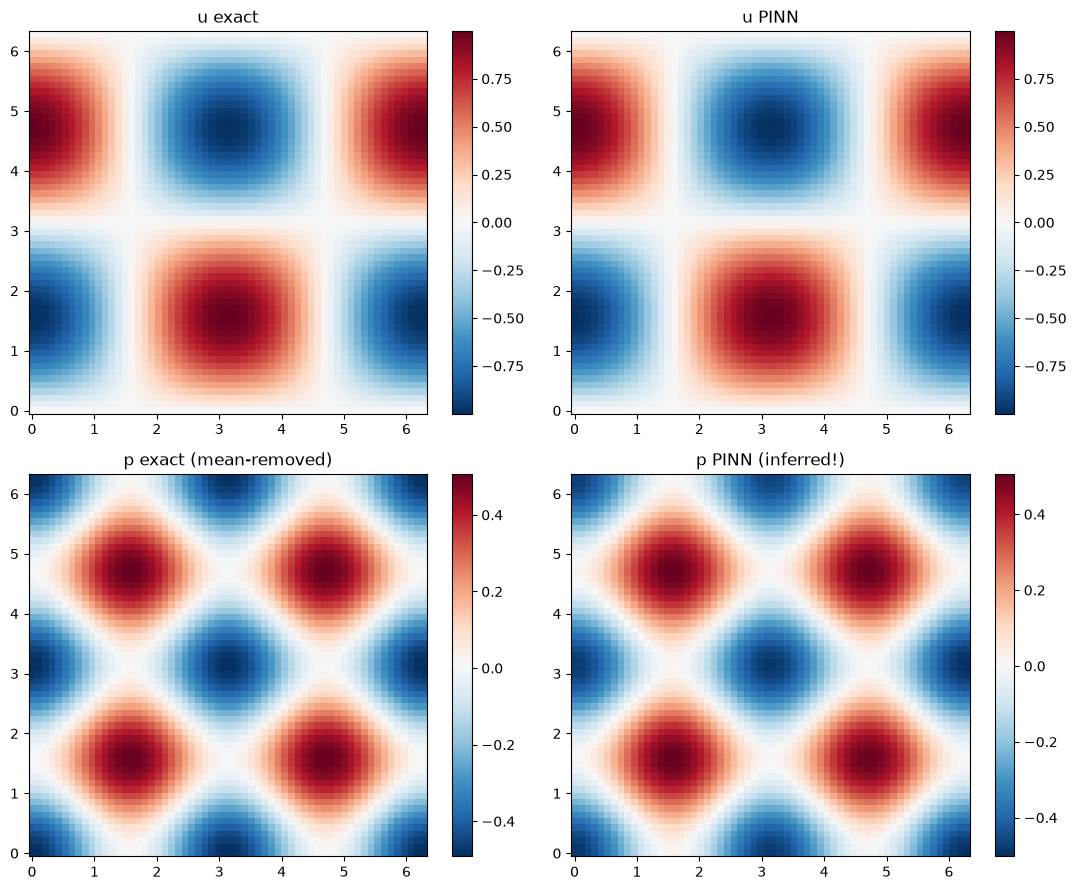

pressure rel L2: 0.02816806044144494


In [6]:
# --- Reconstruct fields at t=0 and compare (pressure up to a constant) ---
n=60; gx=np.linspace(0,2*np.pi,n); gy=np.linspace(0,2*np.pi,n)
X,Y=np.meshgrid(gx,gy); Tt=np.zeros_like(X)
xt,yt,tt=to_t(X.ravel()),to_t(Y.ravel()),to_t(Tt.ravel())
xt.requires_grad_(True); yt.requires_grad_(True); tt.requires_grad_(True)
u_pr,v_pr,p_pr = uvp(model,xt,yt,tt)
u_pr=u_pr.detach().cpu().numpy().reshape(n,n)
p_pr=p_pr.detach().cpu().numpy().reshape(n,n)
ue,ve,pe = tg(X,Y,Tt)
p_pr -= p_pr.mean(); pe -= pe.mean()      # pressure is only defined up to a constant

fig,ax=plt.subplots(2,2,figsize=(11,9))
for a,(d,ttl) in zip(ax.ravel(),
        [(ue,'u exact'),(u_pr,'u PINN'),(pe,'p exact (mean-removed)'),(p_pr,'p PINN (inferred!)')]):
    im=a.pcolormesh(X,Y,d,shading='auto',cmap='RdBu_r'); a.set_title(ttl); fig.colorbar(im,ax=a)
plt.tight_layout(); plt.show()
print("pressure rel L2:", np.linalg.norm(p_pr-pe)/np.linalg.norm(pe))


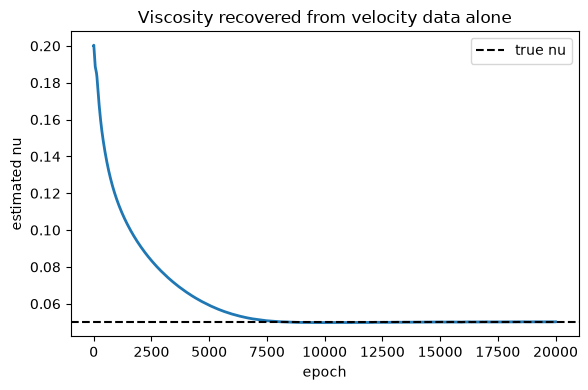

In [7]:
plt.figure(figsize=(6,4))
plt.plot(nu_hist, lw=2); plt.axhline(nu_true, color='k', ls='--', label='true nu')
plt.xlabel('epoch'); plt.ylabel('estimated nu'); plt.legend()
plt.title('Viscosity recovered from velocity data alone'); plt.tight_layout(); plt.show()


## 2 · What makes this a faithful reproduction

- **Pressure is never in the data.** It is reconstructed purely because it is the
  only field consistent with the momentum equations and the observed velocities —
  exactly the "hidden" quantity Raissi et al. recover.
- **Stream-function trick** enforces `∇·u = 0` exactly, removing the continuity
  residual and improving conditioning.
- **Inverse viscosity** shows the same machinery discovers a physical constant.

To reproduce the *original* cylinder-wake result, swap the Taylor–Green data
generator for the authors' `cylinder_nektar_wake.mat` dataset (linked in the
bibliography) and keep everything else. The reported viscosity/`Re` recovery is
within ~1% of truth.

## 3 · Extensions
1. Add L-BFGS after Adam and measure the accuracy jump.
2. Use the real cylinder-wake dataset and reproduce Table 1 of the paper.
3. Replace the plain MLP with a modified-MLP / Fourier-feature backbone
   (notebook 12) and compare convergence.
